<a href="https://colab.research.google.com/github/jpcampos04/2605_leaf_diseases_cv/blob/main/2605_leaf_diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle -q

In [2]:
import os
import json

# ✏️ Reemplaza estos valores con los tuyos
KAGGLE_USERNAME = "jospablocampos"
KAGGLE_KEY = "KGAT_2f7b42da721d37af2975e06badb9aaf0"

# Crear el archivo kaggle.json automáticamente
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

kaggle_credentials = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

kaggle_path = os.path.expanduser("~/.kaggle/kaggle.json")

with open(kaggle_path, "w") as f:
    json.dump(kaggle_credentials, f)

os.chmod(kaggle_path, 0o600)

print("✅ Credenciales configuradas correctamente")

✅ Credenciales configuradas correctamente


In [3]:
# Reemplaza con tu dataset
DATASET = "yusufmurtaza01/tomato-leaf-disease"

!kaggle datasets download -d {DATASET} --path /content/data
print("✅ Descarga completa")

Dataset URL: https://www.kaggle.com/datasets/yusufmurtaza01/tomato-leaf-disease
License(s): CC0-1.0
100% 445M/445M [00:07<00:00, 61.1MB/s]

✅ Descarga completa


In [4]:
import zipfile, os

zip_path = "/content/data"

# Descomprime todos los .zip encontrados
for f in os.listdir(zip_path):
    if f.endswith(".zip"):
        full_path = os.path.join(zip_path, f)
        print(f"Descomprimiendo {f}...")
        with zipfile.ZipFile(full_path, "r") as zip_ref:
            zip_ref.extractall(zip_path)
        print(f"✅ {f} descomprimido")

# Ver estructura resultante
for root, dirs, files in os.walk(zip_path):
    level = root.replace(zip_path, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for file in files[:5]:  # Muestra solo los primeros 5 por carpeta
            print(f"{indent}  {file}")

Descomprimiendo tomato-leaf-disease.zip...
✅ tomato-leaf-disease.zip descomprimido
data/
  Labels_Counts.png
  tomato-leaf-disease.zip
  Images_Counts.png
  tomato/
    data.yaml
    labels/
      train/
      val/
    images/
      train/
      val/


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Verificar GPU disponible
print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU disponible: []


In [6]:
import yaml

with open("/content/data/tomato/data.yaml", "r") as f:
    config = yaml.safe_load(f)

class_names = config["names"]
num_classes = len(class_names)

print(f"Número de clases: {num_classes}")
print(f"Clases: {class_names}")

Número de clases: 10
Clases: ['Tomato__BacterialSpot', 'Tomato__EarlyBlight', 'Tomato__Healthy', 'Tomato__LateBlight', 'Tomato__LeafMold', 'Tomato__MosaicVirus', 'Tomato__SeptoriaLeafSpot', 'Tomato__SpiderMites', 'Tomato__TargetSpot', 'Tomato__YellowLeafCurlVirus']


In [7]:
import pandas as pd
from pathlib import Path

def build_dataframe(split):
    images_dir = Path(f"/content/data/tomato/images/{split}")
    labels_dir = Path(f"/content/data/tomato/labels/{split}")

    records = []
    for img_path in images_dir.iterdir():
        label_path = labels_dir / (img_path.stem + ".txt")
        if label_path.exists():
            with open(label_path) as f:
                first_line = f.readline().strip()
                if first_line:
                    class_idx = int(first_line.split()[0])
                    records.append({
                        "image_path": str(img_path),
                        "class_idx": class_idx,
                        "class_name": class_names[class_idx]
                    })

    return pd.DataFrame(records)

df_train = build_dataframe("train")
df_val   = build_dataframe("val")

print(f"Train: {len(df_train)} imágenes")
print(f"Val:   {len(df_val)} imágenes")
print("\nDistribución de clases (train):")
print(df_train["class_name"].value_counts())

Train: 12168 imágenes
Val:   3041 imágenes

Distribución de clases (train):
class_name
Tomato__YellowLeafCurlVirus    1600
Tomato__LateBlight             1599
Tomato__BacterialSpot          1598
Tomato__SeptoriaLeafSpot       1536
Tomato__SpiderMites            1343
Tomato__Healthy                1322
Tomato__TargetSpot             1124
Tomato__EarlyBlight             870
Tomato__LeafMold                834
Tomato__MosaicVirus             342
Name: count, dtype: int64


In [8]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def make_dataset(df, shuffle=False):
    paths  = df["image_path"].values
    labels = tf.keras.utils.to_categorical(df["class_idx"].values, num_classes)

    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = preprocess_input(img)  # Normalización para EfficientNet
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(df_train, shuffle=True)
val_ds   = make_dataset(df_val,   shuffle=False)

print("✅ Datasets listos")

✅ Datasets listos


In [9]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

# Base preentrenada en ImageNet
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Congelamos primero

# Cabeza de clasificación
inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df_train["class_idx"]),
    y=df_train["class_idx"]
)

class_weight_dict = dict(enumerate(class_weights_array))

print("Pesos por clase:")
for idx, weight in class_weight_dict.items():
    print(f"  {class_names[idx]:<35} → {weight:.3f}")

Pesos por clase:
  Tomato__BacterialSpot               → 0.761
  Tomato__EarlyBlight                 → 1.399
  Tomato__Healthy                     → 0.920
  Tomato__LateBlight                  → 0.761
  Tomato__LeafMold                    → 1.459
  Tomato__MosaicVirus                 → 3.558
  Tomato__SeptoriaLeafSpot            → 0.792
  Tomato__SpiderMites                 → 0.906
  Tomato__TargetSpot                  → 1.083
  Tomato__YellowLeafCurlVirus         → 0.760


In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,  # 👈 línea añadida
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
    ]
)

Epoch 1/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1158s 3s/step - accuracy: 0.6786 - loss: 1.1189 - val_accuracy: 0.8448 - val_loss: 0.6304 - learning_rate: 0.0010
Epoch 2/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1105s 3s/step - accuracy: 0.8254 - loss: 0.6263 - val_accuracy: 0.8750 - val_loss: 0.4699 - learning_rate: 0.0010
Epoch 3/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1082s 3s/step - accuracy: 0.8557 - loss: 0.5134 - val_accuracy: 0.8938 - val_loss: 0.3935 - learning_rate: 0.0010
Epoch 4/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1149s 3s/step - accuracy: 0.8697 - loss: 0.4541 - val_accuracy: 0.8987 - val_loss: 0.3584 - learning_rate: 0.0010
Epoch 5/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1125s 3s/step - accuracy: 0.8772 - loss: 0.4151 - val_accuracy: 0.9037 - val_loss: 0.3425 - learning_rate: 0.0010
Epoch 6/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1079s 3s/step - accuracy: 0.8845 - loss: 0.3933 - val_accuracy: 0.9115 - val_loss: 0.3214 - learning_rate: 0.0010
Epoch 7/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1125s 3s/step - accuracy: 0.8825 - l

In [12]:
# Descongelar las últimas 30 capas de EfficientNetB0
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompilar con learning rate mucho más bajo
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # 100x más bajo que antes
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Parámetros entrenables ahora: {trainable_count:,}")

Parámetros entrenables ahora: 1,508,970


In [13]:
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=2)
    ]
)

Epoch 1/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1308s 3s/step - accuracy: 0.7924 - loss: 0.6414 - val_accuracy: 0.8912 - val_loss: 0.3612 - learning_rate: 1.0000e-05
Epoch 2/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1292s 3s/step - accuracy: 0.8457 - loss: 0.4819 - val_accuracy: 0.9063 - val_loss: 0.3114 - learning_rate: 1.0000e-05
Epoch 3/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1241s 3s/step - accuracy: 0.8668 - loss: 0.4050 - val_accuracy: 0.9142 - val_loss: 0.2755 - learning_rate: 1.0000e-05
Epoch 4/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1292s 3s/step - accuracy: 0.8813 - loss: 0.3645 - val_accuracy: 0.9234 - val_loss: 0.2512 - learning_rate: 1.0000e-05
Epoch 5/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1294s 3s/step - accuracy: 0.8889 - loss: 0.3350 - val_accuracy: 0.9296 - val_loss: 0.2312 - learning_rate: 1.0000e-05
Epoch 6/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1289s 3s/step - accuracy: 0.9057 - loss: 0.2909 - val_accuracy: 0.9342 - val_loss: 0.2170 - learning_rate: 1.0000e-05
Epoch 7/10
381/381 ━━━━━━━━━━━━━━━━━━━━ 1292s 3s/ste

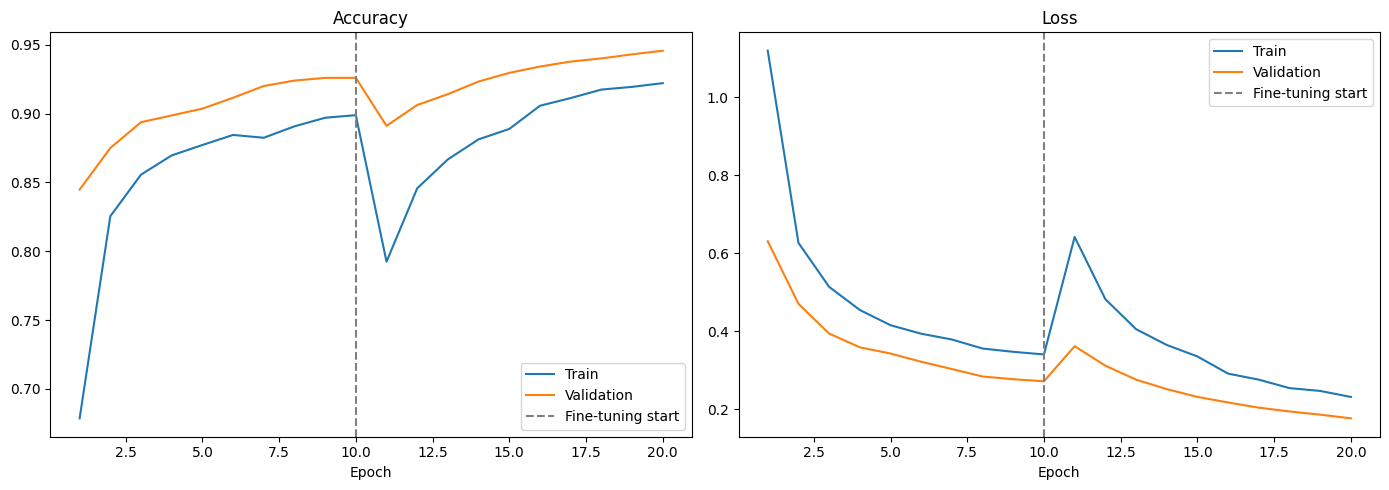

✅ Gráfica guardada


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combinar historial de ambas fases
acc     = history.history["accuracy"]     + history_ft.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_ft.history["val_accuracy"]
loss    = history.history["loss"]         + history_ft.history["loss"]
val_loss= history.history["val_loss"]     + history_ft.history["val_loss"]

epochs_total = range(1, len(acc) + 1)
fine_tune_start = len(history.history["accuracy"])

for ax, train_m, val_m, title in zip(
    axes,
    [acc, loss],
    [val_acc, val_loss],
    ["Accuracy", "Loss"]
):
    ax.plot(epochs_total, train_m, label="Train")
    ax.plot(epochs_total, val_m, label="Validation")
    ax.axvline(fine_tune_start, color="gray", linestyle="--", label="Fine-tuning start")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.savefig("/content/data/training_curves.png", dpi=150)
plt.show()
print("✅ Gráfica guardada")

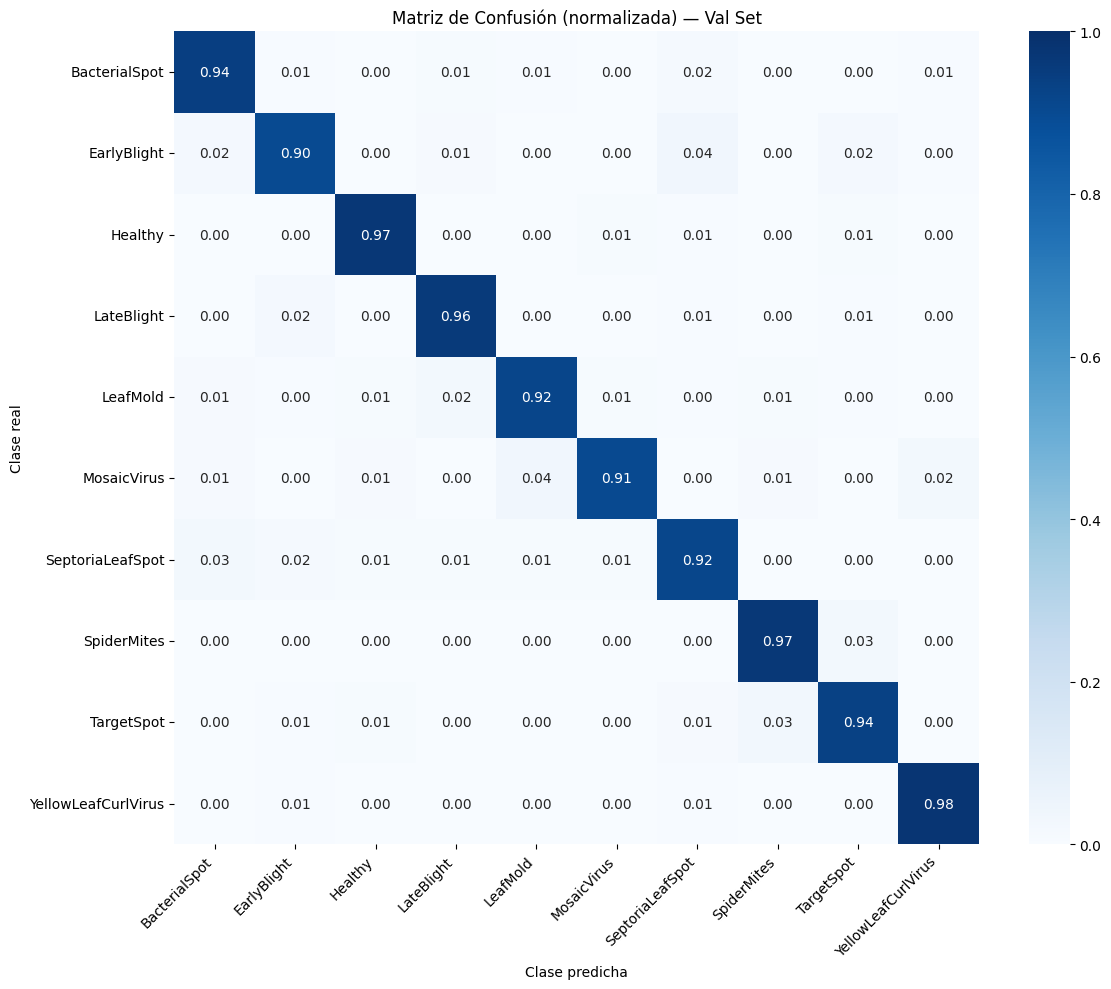


Classification Report:
                     precision    recall  f1-score   support

      BacterialSpot       0.95      0.94      0.95       400
        EarlyBlight       0.89      0.90      0.89       218
            Healthy       0.97      0.97      0.97       332
         LateBlight       0.96      0.96      0.96       400
           LeafMold       0.93      0.92      0.92       208
        MosaicVirus       0.86      0.91      0.88        85
   SeptoriaLeafSpot       0.93      0.92      0.92       383
        SpiderMites       0.96      0.97      0.96       335
         TargetSpot       0.92      0.94      0.93       280
YellowLeafCurlVirus       0.98      0.98      0.98       400

           accuracy                           0.95      3041
          macro avg       0.94      0.94      0.94      3041
       weighted avg       0.95      0.95      0.95      3041



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Obtener predicciones
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)  # Normalizada

# Nombres cortos para el gráfico
short_names = [c.replace("Tomato__", "") for c in class_names]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot=True, fmt=".2f",
    xticklabels=short_names,
    yticklabels=short_names,
    cmap="Blues",
    vmin=0, vmax=1
)
plt.title("Matriz de Confusión (normalizada) — Val Set")
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/data/confusion_matrix.png", dpi=150)
plt.show()

# Reporte por clase
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=short_names))

In [16]:
model.save("/content/data/tomato_disease_model.keras")
print("✅ Modelo guardado en /content/data/tomato_disease_model.keras")

✅ Modelo guardado en /content/data/tomato_disease_model.keras
